In [ ]:
## IDW Interpolation Performance Evaluation
# Last updated: 10/30/25

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import rasterio as rio
import matplotlib.ticker as mticker
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.colors import TwoSlopeNorm
import geopandas as gpd
from rasterio.plot import show as rio_show
from scipy.interpolate import griddata
import matplotlib.patches as mpatches
from pyproj import Transformer
from rasterio.warp import calculate_default_transform, reproject, Resampling
import rasterio as rio

# PATHS
BASE_DIR = Path().resolve().parent

CONFIG = {
    "station_meta_csv": BASE_DIR / "Data/Stations/station_metadata_20241001_20250531.csv",
    "station_dir":      BASE_DIR / "Data/Stations",   # per-station CSVs
    "imerg_dir":        BASE_DIR / "Data/IMERG",      # parquet (wide)
    "mros_parquet":     BASE_DIR / "Data/observations/wy25_mros_obs.parquet",
    "dem_path":         BASE_DIR / "DEM_1km_clipped.tif", # final clipped DEM
    "out_dir":          BASE_DIR / "outputs/hourly_pipeline",
    "idw_nc":           Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/IDW/hourly_predictors_1km_IDW_v3_test.nc") # too large to store on github so saved locally and in Google Drive data folder
}

VARS = ["mros_plp_proxy", "plp", "temp_air", "temp_wet", "temp_dew", "rh"]
XNAME, YNAME, TNAME = "x", "y", "time"
OUT_DIR = Path(CONFIG["out_dir"])

# Create an evaluation subfolder for results
eval_dir = OUT_DIR / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)


start_time = pd.to_datetime("2025-03-30 00:00")
end_time   = pd.to_datetime("2025-04-02 23:00")


In [94]:
# LOAD IDW GRID 

print("\n--- Loading IDW dataset ---")
idw = xr.open_dataset(CONFIG["idw_nc"])
print(idw)
print("Variables:", list(idw.data_vars))
print("Time range:", str(idw["time"].values[0]), "→", str(idw["time"].values[-1]))

# LOAD OBSERVATION DATASETS
print("\n--- Loading observations ---")
st_hr   = pd.read_parquet(OUT_DIR / "hourly_data/stations_hourly.parquet")
imerg_hr = pd.read_parquet(OUT_DIR / "hourly_data/imerg_hourly.parquet")
mros_hr  = pd.read_parquet(OUT_DIR / "hourly_data/mros_hourly.parquet")
print("Stations:", st_hr.shape, "IMERG:", imerg_hr.shape, "MRoS:", mros_hr.shape)

# Normalize timezone before window subset
imerg_hr["hour_utc"] = pd.to_datetime(imerg_hr["hour_utc"], utc=True).dt.tz_localize(None)

imerg_window = imerg_hr[
    (imerg_hr["hour_utc"] >= start_time) &
    (imerg_hr["hour_utc"] <= end_time)
].copy()

print("\nIMERG subset time coverage:")
print(imerg_window["hour_utc"].min(), "→", imerg_window["hour_utc"].max())
print("Unique hours:", imerg_window["hour_utc"].nunique())


--- Loading IDW dataset ---
<xarray.Dataset> Size: 88MB
Dimensions:         (time: 96, y: 260, x: 146)
Coordinates:
  * y               (y) float64 2kB 4.425e+06 4.424e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.633e+05 1.643e+05 ... 3.018e+05 3.028e+05
  * time            (time) datetime64[ns] 768B 2025-03-30 ... 2025-04-02T23:0...
Data variables:
    temp_air        (time, y, x) float32 15MB ...
    temp_dew        (time, y, x) float32 15MB ...
    temp_wet        (time, y, x) float32 15MB ...
    rh              (time, y, x) float32 15MB ...
    mros_plp_proxy  (time, y, x) float32 15MB ...
    plp             (time, y, x) float32 15MB ...
    elev            (y, x) float32 152kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162846.25611536083 961.820446988464 0.0 4425513.051449...
Variables: ['


--- IMERG Hourly Data Summary ---
<class 'pandas.core.frame.DataFrame'>
Index: 6966000 entries, 1 to 7358128
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   hour_utc  datetime64[ns]
 1   lat       float64       
 2   lon       float64       
 3   plp       float64       
 4   elev      float32       
dtypes: datetime64[ns](1), float32(1), float64(3)
memory usage: 292.3 MB
None

Total records: 6,966,000

IMERG time range:
Min: 2024-10-11 00:00:00
Max: 2025-05-30 23:00:00

--- IMERG subset for test window ---
(64800, 5)
5304721   2025-04-01 00:00:00
5306147   2025-04-01 01:00:00
5307573   2025-04-01 02:00:00
5308999   2025-04-01 03:00:00
5310425   2025-04-01 04:00:00
5311851   2025-04-01 05:00:00
5313277   2025-04-01 06:00:00
5314703   2025-04-01 07:00:00
5316129   2025-04-01 08:00:00
5317555   2025-04-01 09:00:00
5318981   2025-04-01 10:00:00
5320407   2025-04-01 11:00:00
5321833   2025-04-01 12:00:00
5323259   2025-04-01 13:00:00
532468

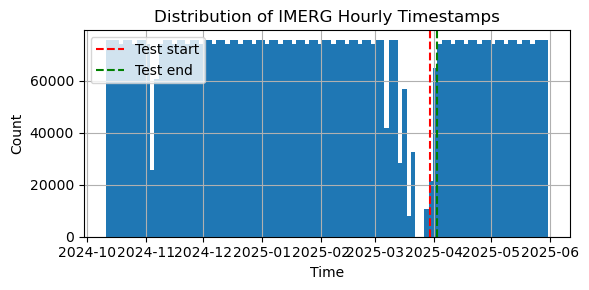


--- PLP Distribution within test window ---
count    64800.000000
mean        51.153981
std         45.629299
min          0.000000
1%           0.000000
25%          3.000000
50%         42.000000
75%        100.000000
99%        100.000000
max        100.000000
Name: plp, dtype: float64


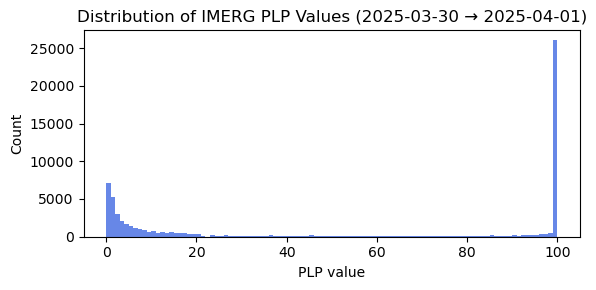

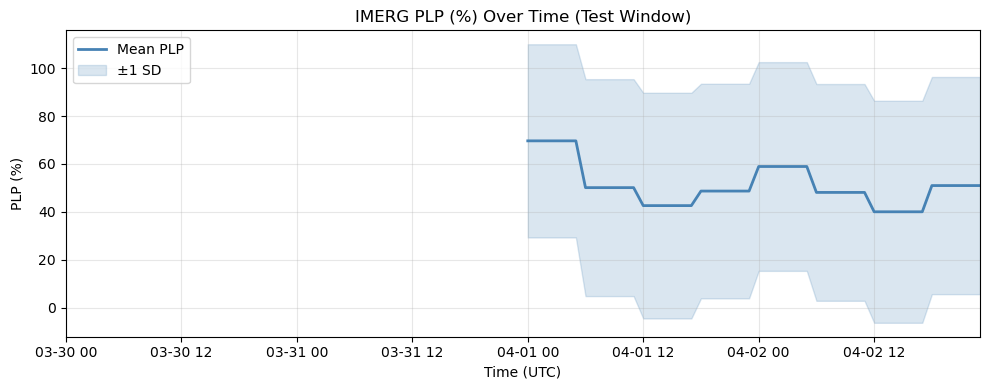

In [95]:
# Quick check on IMERG dataset

# Basic metadata
print("\n--- IMERG Hourly Data Summary ---")
print(imerg_hr.info())
print(f"\nTotal records: {len(imerg_hr):,}")

# Show time coverage
print("\nIMERG time range:")
print("Min:", imerg_hr["hour_utc"].min())
print("Max:", imerg_hr["hour_utc"].max())

imerg_window = imerg_hr[
    (imerg_hr["hour_utc"] >= start_time) &
    (imerg_hr["hour_utc"] <= end_time)
].copy()


print("\n--- IMERG subset for test window ---")
print(imerg_window.shape)
print(imerg_window["hour_utc"].drop_duplicates().sort_values().head(20))

plt.figure(figsize=(6,3))
imerg_hr["hour_utc"].hist(bins=100)
plt.axvline(start_time, color="r", linestyle="--", label="Test start")
plt.axvline(end_time, color="g", linestyle="--", label="Test end")
plt.title("Distribution of IMERG Hourly Timestamps")
plt.xlabel("Time")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# --- Distribution of PLP values in test window ---
print("\n--- PLP Distribution within test window ---")

# Subset
imerg_window = imerg_hr[
    (imerg_hr["hour_utc"] >= start_time) &
    (imerg_hr["hour_utc"] <= end_time)
].copy()

# Drop missing / nodata
valid_plp = imerg_window["plp"].dropna()

# Print summary stats
print(valid_plp.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

# Plot histogram
plt.figure(figsize=(6,3))
plt.hist(valid_plp, bins=100, color="royalblue", alpha=0.8)
plt.xlabel("PLP value")
plt.ylabel("Count")
plt.title("Distribution of IMERG PLP Values (2025-03-30 → 2025-04-01)")
plt.tight_layout()
plt.show()


# --- Time series of mean PLP with variability band ---
plp_timeseries = (
    imerg_window.groupby("hour_utc")["plp"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(10,4))
plt.plot(plp_timeseries["hour_utc"], plp_timeseries["mean"],
         color="steelblue", lw=2, label="Mean PLP")
plt.fill_between(
    plp_timeseries["hour_utc"],
    plp_timeseries["mean"] - plp_timeseries["std"],
    plp_timeseries["mean"] + plp_timeseries["std"],
    color="steelblue", alpha=0.2, label="±1 SD"
)
plt.title("IMERG PLP (%) Over Time (Test Window)")
plt.xlabel("Time (UTC)")
plt.ylabel("PLP (%)")
plt.xlim(start_time, end_time)          # ← restrict to window
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()




In [96]:
# WIDE → LONG CONVERSION
def melt_obs(df, vars_, source):
    df = df.copy()
    df = df.melt(
        id_vars=["hour_utc", "lat", "lon", "elev"],
        value_vars=[v for v in vars_ if v in df.columns],
        var_name="var", value_name="obs_value"
    )
    df = df.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})
    df["source"] = source
    return df

st_long   = melt_obs(st_hr,   ["temp_air","temp_wet","temp_dew","rh"], "stations")
imerg_long= melt_obs(imerg_hr,["plp"], "imerg")
mros_long = melt_obs(mros_hr, ["mros_plp_proxy"], "mros")

obs_all = pd.concat([st_long, imerg_long, mros_long], ignore_index=True)
print(f"\nCombined observations: {obs_all.shape[0]} records")


Combined observations: 9204960 records


In [97]:
# DATETIME HANDLING
print("\n--- Checking time formats (tz-aware vs naive) ---")
print("Observation time dtype:", obs_all["time"].dtype)
print("IDW time dtype:", idw["time"].dtype)

# Ensure tz-naive alignment
obs_all["time"] = pd.to_datetime(obs_all["time"], utc=True).dt.floor("h").dt.tz_localize(None)
idw_times = pd.to_datetime(idw["time"].values).tz_localize(None)

print("Obs time example:", obs_all["time"].iloc[0])
print("IDW time example:", idw_times[0])

# Filter observations within IDW time window
obs_all = obs_all[
    (obs_all["time"] >= idw_times.min()) &
    (obs_all["time"] <= idw_times.max())
]
print(f"Filtered to {obs_all['time'].min()} → {obs_all['time'].max()}")


--- Checking time formats (tz-aware vs naive) ---
Observation time dtype: object
IDW time dtype: datetime64[ns]
Obs time example: 2024-10-01 08:00:00
IDW time example: 2025-03-30 00:00:00
Filtered to 2025-03-30 00:00:00 → 2025-04-02 23:00:00



--- Loading DEM and ensuring projected CRS ---
DEM is geographic (EPSG:4326); reprojecting to EPSG:26911 ...
DEM CRS: EPSG:26911, pixel size: 961.82 m

--- Reprojecting observation coordinates to DEM CRS ---
Obs X range: 141892.1651359729 → 410306.4481214098
Obs Y range: 3934545.6594123975 → 4429683.458391626
Grid X range: 163327.16633885505 → 302791.13115218235
Grid Y range: 4175920.6454562386 → 4425032.141226251


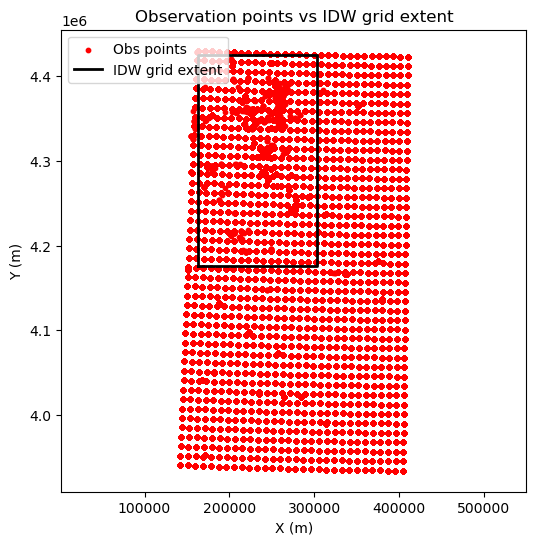

In [98]:
# REPROJECT COORDINATES TO MATCH IDW GRID CRS

# LOAD AND VERIFY DEM CRS
print("\n--- Loading DEM and ensuring projected CRS ---")

# Optional fallback projection
CONFIG["proj_fallback"] = "EPSG:26911"   # NAD83 / UTM zone 11N (units: meters)

def grid_centers(profile):
    """Compute projected x,y coordinates (in meters) for every pixel center in the DEM."""
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])

with rio.open(CONFIG["dem_path"]) as src:
    dem_crs = src.crs
    if not dem_crs or not dem_crs.is_projected:
        print(f"DEM is geographic ({dem_crs}); reprojecting to {CONFIG['proj_fallback']} ...")
        dst_crs = CONFIG["proj_fallback"]
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": dst_crs,
            "transform": transform,
            "width": width,
            "height": height
        })
        dem_data = np.empty((height, width), dtype=np.float32)
        reproject(
            source=rio.band(src, 1),
            destination=dem_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear)
        dem_profile = kwargs
        proj_crs = dst_crs
    else:
        dem_profile = src.profile
        dem_data = src.read(1)
        proj_crs = dem_crs

grid_xy = grid_centers(dem_profile)
print(f"DEM CRS: {proj_crs}, pixel size: {abs(dem_profile['transform'].a):.2f} m")

# REPROJECT OBSERVATION COORDINATES TO DEM CRS
print("\n--- Reprojecting observation coordinates to DEM CRS ---")

transformer = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
lon = obs_all["x"].values
lat = obs_all["y"].values
x_m, y_m = transformer.transform(lon, lat)
obs_all["x"] = x_m
obs_all["y"] = y_m

print("Obs X range:", obs_all["x"].min(), "→", obs_all["x"].max())
print("Obs Y range:", obs_all["y"].min(), "→", obs_all["y"].max())
print("Grid X range:", float(idw["x"].min()), "→", float(idw["x"].max()))
print("Grid Y range:", float(idw["y"].min()), "→", float(idw["y"].max()))

# VISUAL OVERLAP CHECK
plt.figure(figsize=(6,6))
plt.scatter(obs_all["x"], obs_all["y"], s=10, color="red", label="Obs points")
plt.plot(
    [idw["x"].min(), idw["x"].max(), idw["x"].max(), idw["x"].min(), idw["x"].min()],
    [idw["y"].min(), idw["y"].min(), idw["y"].max(), idw["y"].max(), idw["y"].min()],
    color="black", lw=2, label="IDW grid extent"
)
plt.legend()
plt.title("Observation points vs IDW grid extent")
plt.xlabel("X (m)"); plt.ylabel("Y (m)")
plt.axis("equal")
plt.show()


In [99]:
x_min, x_max = float(idw["x"].min()), float(idw["x"].max())
y_min, y_max = float(idw["y"].min()), float(idw["y"].max())

inside_mask = (
    (obs_all["x"] >= x_min) & (obs_all["x"] <= x_max) &
    (obs_all["y"] >= y_min) & (obs_all["y"] <= y_max)
)
coverage = inside_mask.mean() * 100
print(f"{coverage:.1f}% of observation points fall inside the IDW grid extent.")


37.4% of observation points fall inside the IDW grid extent.


In [100]:
# Subset to overlapping points
obs_all = obs_all.loc[inside_mask].copy()
print(f"Using {len(obs_all)} observations within grid extent.")

Using 32814 observations within grid extent.


In [101]:
# SAMPLING FUNCTION --------------------------
def sample_ds_at_points(ds, points_long, var, xname="x", yname="y", tname="time"):
    """
    Sample gridded variable at observation coordinates + times (IDW dataset).
    Uses nearest-time selection with a tolerance to avoid dtype/precision mismatches.
    """
    sub = points_long.loc[points_long["var"] == var].copy()
    if sub.empty:
        print(f"No data for var {var}")
        return np.array([])

    # ensure numpy datetime64[ns] to align with xarray index dtype
    sub["time64"] = sub["time"].values.astype("datetime64[ns]")

    results = []
    valid_count = 0

    for t, g in sub.groupby("time64", sort=True):
        try:
            # first try with 30-minute tolerance
            f_time = ds[var].sel({tname: t}, method="nearest", tolerance=np.timedelta64(30, "m"))
        except Exception:
            # fall back to plain nearest if outside tolerance
            try:
                f_time = ds[var].sel({tname: t}, method="nearest")
            except Exception as e:
                # skip this hour if selection truly fails
                # print(f"{var}: could not select time {t}: {e}")
                continue

        sampled = f_time.interp(
            {xname: xr.DataArray(g[xname].values, dims="obs"),
             yname: xr.DataArray(g[yname].values, dims="obs")}
        )
        results.append(pd.Series(sampled.values, index=g.index))
        valid_count += len(g)

    if not results:
        print(f"No successful interpolations for {var}")
        return np.array([])

    preds = pd.concat(results).sort_index().values
    print(f"Sampled {valid_count} points for {var}")
    return preds


In [102]:
# COMPUTE METRICS + RESIDUALS
records, resids = [], []

for var in VARS:
    if var not in idw.data_vars:
        print(f"Variable {var} missing in dataset, skipping.")
        continue

    sub = obs_all[obs_all["var"] == var].copy()
    pred = sample_ds_at_points(idw, obs_all, var)
    sub["pred"] = pred
    sub["resid"] = sub["pred"] - sub["obs_value"]

    valid_mask = np.isfinite(sub["pred"]) & np.isfinite(sub["obs_value"])
    if valid_mask.sum() == 0:
        print(f"No valid predictions for {var}")
        continue

    rmse = np.sqrt(np.nanmean(sub.loc[valid_mask, "resid"] ** 2))
    mae  = np.nanmean(np.abs(sub.loc[valid_mask, "resid"]))
    bias = np.nanmean(sub.loc[valid_mask, "resid"])
    n    = valid_mask.sum()

    print(f"{var:15s}  RMSE={rmse:.3f}  MAE={mae:.3f}  Bias={bias:.3f}  N={n}")
    records.append({"var": var, "rmse": rmse, "mae": mae, "bias": bias, "n": n})
    resids.append(sub)

metrics = pd.DataFrame(records)
resid_df = pd.concat(resids, ignore_index=True) if resids else pd.DataFrame()

print("\nMetrics summary:")
print(metrics)

Sampled 670 points for mros_plp_proxy
mros_plp_proxy   RMSE=6.069  MAE=1.707  Bias=-0.018  N=654
Sampled 16848 points for plp
plp              RMSE=0.094  MAE=0.044  Bias=-0.002  N=15840
Sampled 3824 points for temp_air
temp_air         RMSE=0.243  MAE=0.189  Bias=-0.056  N=3820
Sampled 3824 points for temp_wet
temp_wet         RMSE=0.242  MAE=0.189  Bias=-0.056  N=3820
Sampled 3824 points for temp_dew
temp_dew         RMSE=0.271  MAE=0.206  Bias=-0.054  N=3824
Sampled 3824 points for rh
rh               RMSE=0.080  MAE=0.045  Bias=0.004  N=3824

Metrics summary:
              var      rmse       mae      bias      n
0  mros_plp_proxy  6.068824  1.706791 -0.018115    654
1             plp  0.094346  0.043513 -0.002265  15840
2        temp_air  0.243155  0.188894 -0.056436   3820
3        temp_wet  0.242142  0.189399 -0.056250   3820
4        temp_dew  0.270558  0.205995 -0.053513   3824
5              rh  0.080474  0.045473  0.003995   3824



--- PLP Hourly Sample Counts ---
 hour  n_samples
    0        702
    1        702
    2        702
    3        702
    4        702
    5        702
    6        702
    7        702
    8        702
    9        702
   10        702
   11        702
   12        702
   13        702
   14        702
   15        702
   16        702
   17        702
   18        702
   19        702
   20        702
   21        702
   22        702
   23        702


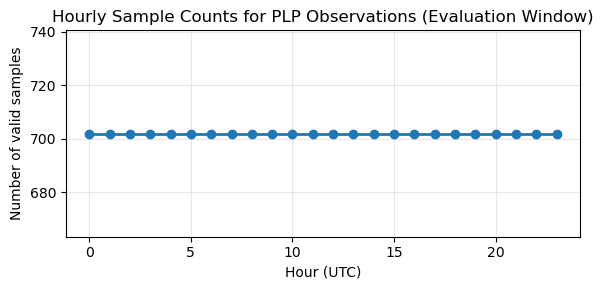

plp unique hours in obs: 48
temp_air unique hours in obs: 96
temp_wet unique hours in obs: 96
temp_dew unique hours in obs: 96
rh unique hours in obs: 96
mros_plp_proxy unique hours in obs: 72


In [103]:
# Checking

# --- Compute hourly sample counts for PLP ---
df_plp = resid_df[resid_df["var"] == "plp"].copy()
df_plp = df_plp.dropna(subset=["time", "obs_value"])  # drop missing observations
df_plp["hour"] = pd.to_datetime(df_plp["time"]).dt.hour

# Count valid samples per UTC hour
plp_hour_counts = (
    df_plp.groupby("hour")["obs_value"]
    .count()
    .reset_index(name="n_samples")
    .sort_values("hour")
)

print("\n--- PLP Hourly Sample Counts ---")
print(plp_hour_counts.to_string(index=False))

# Optional: plot sample counts
plt.figure(figsize=(6,3))
plt.plot(plp_hour_counts["hour"], plp_hour_counts["n_samples"], marker="o", lw=2)
plt.title("Hourly Sample Counts for PLP Observations (Evaluation Window)")
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of valid samples")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# How many unique hours per variable after sampling?
for v in ["plp", "temp_air", "temp_wet", "temp_dew", "rh", "mros_plp_proxy"]:
    sub = obs_all[obs_all["var"] == v]
    print(v, "unique hours in obs:", sub["time"].nunique())



In [106]:
PALETTE = "crest"

# -------------------------------------------------------------------
# 1. RMSE BAR CHART
# -------------------------------------------------------------------
def plot_rmse_bar(metrics_df, outdir=None):
    """
    Simple RMSE bar chart per variable for IDW results.
    """
    df = metrics_df.copy().sort_values("rmse")
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x="var", y="rmse", color="steelblue")
    plt.title("IDW RMSE by Variable")
    plt.ylabel("RMSE")
    plt.xlabel("Variable")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if outdir:
        plt.savefig(Path(outdir) / "idw_rmse_by_variable.png", dpi=250)
    plt.show()


# -------------------------------------------------------------------
# 2. HEATMAP OF RMSE BY ELEVATION BAND
# -------------------------------------------------------------------
def plot_rmse_heatmap_by_elev(resid_df, outdir=None, bins=(0,1500,2500,4000)):
    """
    Show RMSE variation by elevation band and variable (IDW only).
    """
    df = resid_df.dropna(subset=["elev"])
    df["elev_band"] = pd.cut(df["elev"], bins=bins, include_lowest=True)
    rmse_stats = (
        df.groupby(["var", "elev_band"])
          .agg(rmse=("resid", lambda x: np.sqrt(np.nanmean(x**2))))
          .reset_index()
    )
    pivot = rmse_stats.pivot(index="var", columns="elev_band", values="rmse")

    plt.figure(figsize=(7,4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlBu_r", linewidths=0.4,
    # sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm_r", linewidths=0.4,
                cbar_kws={"label": "RMSE"})
    plt.title("IDW RMSE by Elevation Band")
    plt.xlabel("Elevation band (m)")
    plt.ylabel("Variable")
    plt.tight_layout()
    if outdir:
        plt.savefig(Path(outdir) / "idw_rmse_heatmap_by_elev.png", dpi=250)
    plt.show()


# -------------------------------------------------------------------
# 3. TEMPORAL RMSE TRENDS BY HOUR
# -------------------------------------------------------------------
def plot_rmse_by_hour(resid_df, outdir=None):
    """
    RMSE as a function of hour-of-day for each variable.
    Helps identify diurnal structure in interpolation errors.
    """
    df = resid_df.dropna(subset=["time", "resid"])
    df["hour"] = pd.to_datetime(df["time"]).dt.hour
    hourly_rmse = (
        df.groupby(["var", "hour"])
          .agg(rmse=("resid", lambda x: np.sqrt(np.nanmean(x**2))))
          .reset_index()
    )

    g = sns.FacetGrid(hourly_rmse, col="var", col_wrap=3, height=4, sharey=False)
    g.map_dataframe(sns.lineplot, x="hour", y="rmse", lw=2, color="steelblue", marker="o")
    g.set_axis_labels("Hour (UTC)", "RMSE")
    g.set_titles("{col_name}")
    g.set(xlim=(0,23), xticks=[0,6,12,18,23])
    g.tight_layout()
    if outdir:
        g.savefig(Path(outdir) / "idw_rmse_by_hour.png", dpi=250)
    plt.show()


# -------------------------------------------------------------------
# 4. SPATIAL MEAN RESIDUAL MAPS
# -------------------------------------------------------------------
def plot_spatial_mean_residuals(resid_df, outdir=None, vlim=None):
    """
    Plot mean residuals spatially for each variable.
    """
    df = resid_df.dropna(subset=["x", "y", "resid"])
    mean_resid = df.groupby(["var", "x", "y"])["resid"].mean().reset_index()

    for var in sorted(mean_resid["var"].unique()):
        sub = mean_resid[mean_resid["var"] == var]
        plt.figure(figsize=(7,6))
        norm = TwoSlopeNorm(vcenter=0,
                            vmin=vlim[0] if vlim else sub["resid"].quantile(0.05),
                            vmax=vlim[1] if vlim else sub["resid"].quantile(0.95))
        sc = plt.scatter(sub["x"], sub["y"], c=sub["resid"], s=12, cmap="coolwarm", norm=norm)
        plt.colorbar(sc, label="Mean residual (pred − obs)")
        plt.title(f"Spatial Mean Residuals – {var}")
        plt.xlabel("X (m)")
        plt.ylabel("Y (m)")
        plt.axis("equal")
        plt.tight_layout()
        if outdir:
            plt.savefig(Path(outdir) / f"idw_spatial_mean_residuals_{var}.png", dpi=250)
        plt.show()


# -------------------------------------------------------------------
# 5. RESIDUAL VS PREDICTED DIAGNOSTICS
# -------------------------------------------------------------------
def plot_residual_vs_predicted_grid(resid_df, outdir=None, sample_frac=0.4):
    """
    Plot residual vs predicted for all variables in a single multi-panel figure.
    Each panel shows scatter + smoothed trend line.
    """
    df = resid_df.copy().dropna(subset=["pred", "resid"])
    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, random_state=42)

    vars_ = sorted(df["var"].unique())
    ncols = 3
    nrows = int(np.ceil(len(vars_) / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    for i, var in enumerate(vars_):
        ax = axes[i]
        sub = df[df["var"] == var]
        sns.scatterplot(
            data=sub, x="pred", y="resid",
            alpha=0.3, s=20, color="steelblue", ax=ax
        )
        sns.lineplot(
            data=sub, x="pred", y="resid",
            color="black", lw=2, estimator="mean", ax=ax
        )
        ax.axhline(0, color="k", ls="--", lw=1)
        ax.set_title(var)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Residual (pred − obs)")
        ax.grid(alpha=0.3)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Residual vs Predicted (All Variables, IDW Evaluation)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if outdir:
        plt.savefig(Path(outdir) / "idw_residual_vs_predicted_grid.png", dpi=300)
    plt.show()



# -------------------------------------------------------------------
# 6. RADAR / SPIDER CHART SUMMARY
# -------------------------------------------------------------------
def plot_radar_summary(metrics_df, outdir=None, normalize=True):
    """
    Radar chart summarizing RMSE, MAE, Bias per variable for IDW.
    """
    df = metrics_df.copy()
    metrics = ["rmse", "mae", "bias"]

    if normalize:
        for m in metrics:
            rng = df[m].max() - df[m].min()
            df[m] = (df[m] - df[m].min()) / (rng if rng != 0 else 1)

    num_metrics = len(metrics)
    angles = np.linspace(0, 2*np.pi, num_metrics, endpoint=False).tolist()
    angles += angles[:1]

    vars_ = sorted(df["var"].unique())
    ncols = 3
    nrows = int(np.ceil(len(vars_) / ncols))
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        subplot_kw=dict(polar=True),
        figsize=(4*ncols, 4*nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    for i, var in enumerate(vars_):
        sub = df[df["var"] == var]
        values = sub[metrics].iloc[0].tolist()
        values += values[:1]
        ax = axes[i]
        ax.plot(angles, values, lw=2, color="steelblue")
        ax.fill(angles, values, alpha=0.25, color="steelblue")
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1)
        ax.set_title(var, size=12, pad=10)

    fig.suptitle("IDW Interpolation Performance Summary", fontsize=14)
    plt.tight_layout()
    if outdir:
        plt.savefig(Path(outdir) / "idw_radar_summary.png", dpi=300)
    plt.show()


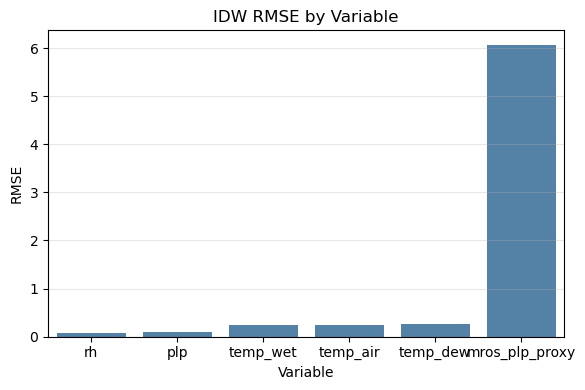

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_43292\552641057.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["var", "elev_band"])


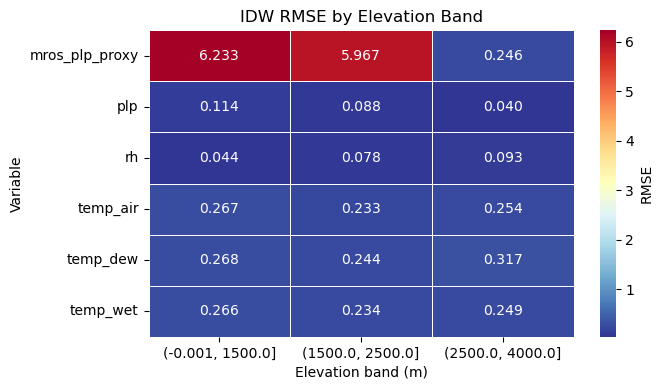

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_43292\552641057.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["hour"] = pd.to_datetime(df["time"]).dt.hour


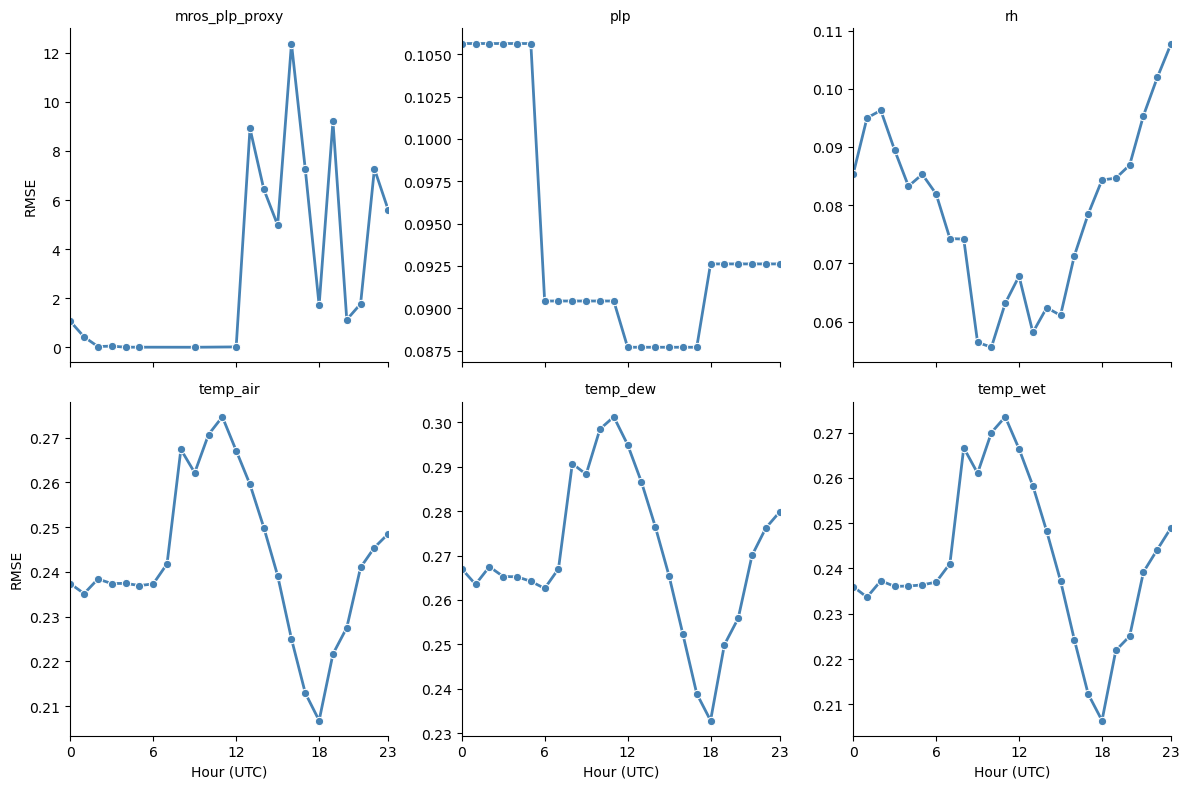

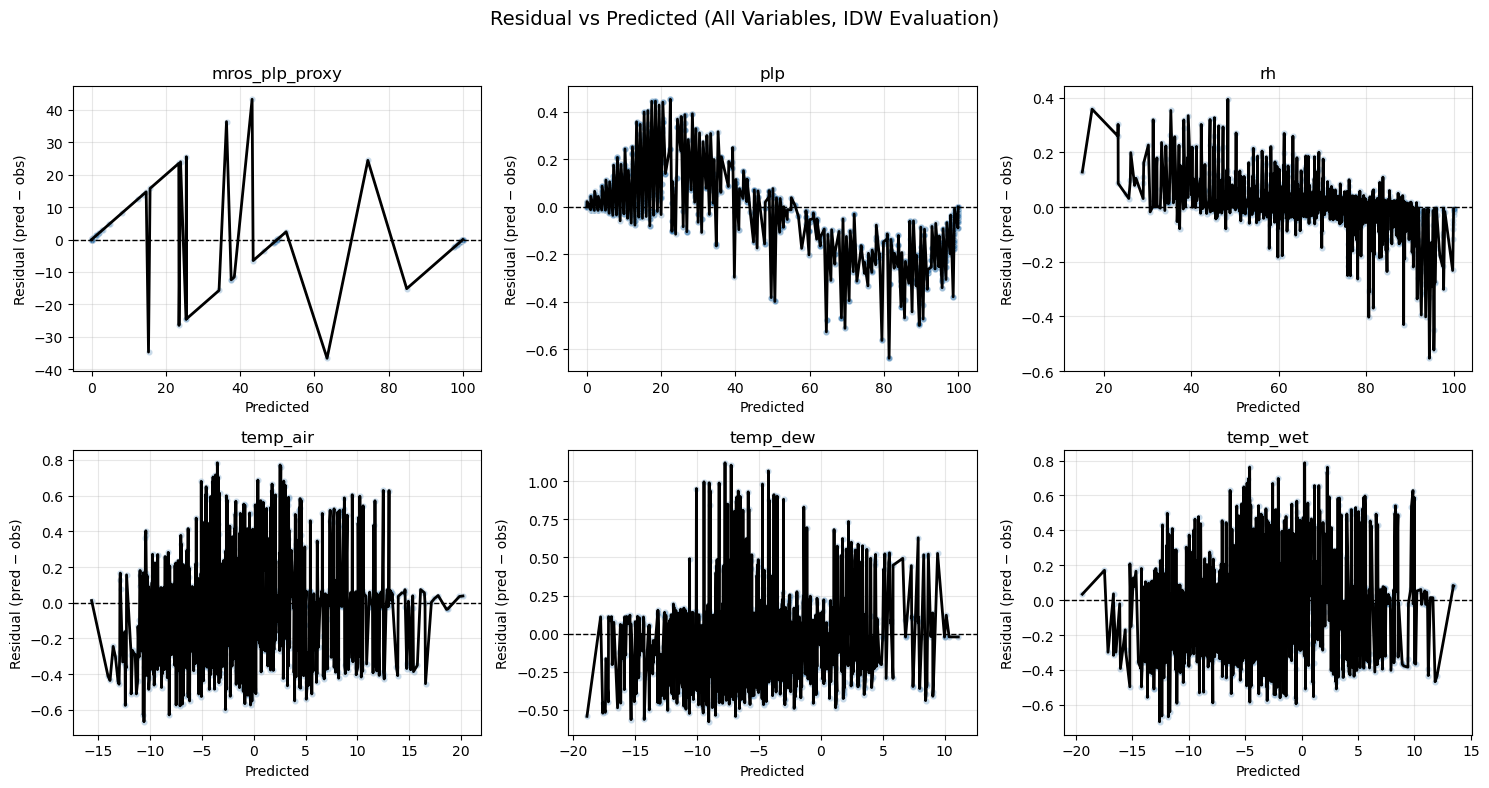

In [107]:
plot_rmse_bar(metrics, outdir=eval_dir)
plot_rmse_heatmap_by_elev(resid_df, outdir=eval_dir)
plot_rmse_by_hour(resid_df, outdir=eval_dir)
# plot_spatial_mean_residuals(resid_df, outdir=eval_dir)
plot_residual_vs_predicted_grid(resid_df, outdir=eval_dir)
# plot_radar_summary(metrics, outdir=eval_dir)

In [ ]:
idw.close()